In [4]:
import time
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Dataset banate hain - baseline comparison ke liye
X, y = make_classification(n_samples=5000, n_features=15, n_informative=8,
                            n_redundant=3, random_state=42)
X = pd.DataFrame(X, columns=[f"f{i}" for i in range(15)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = []

In [5]:
t0 = time.time()
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
t_gb = time.time() - t0

pred = gb.predict(X_test)
proba = gb.predict_proba(X_test)
results.append(["Gradient Boosting (sklearn)", accuracy_score(y_test, pred), log_loss(y_test, proba), t_gb])

print(f"GB Accuracy: {accuracy_score(y_test, pred):.4f} | Time: {t_gb:.2f}s")

GB Accuracy: 0.9400 | Time: 2.71s


In [3]:
!pip install catboost

In [6]:
t0 = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=3,
    tree_method="hist", eval_metric="logloss",
    reg_lambda=1.0, random_state=42
)
xgb_model.fit(X_train, y_train)
t_xgb = time.time() - t0

pred = xgb_model.predict(X_test)
proba = xgb_model.predict_proba(X_test)
results.append(["XGBoost", accuracy_score(y_test, pred), log_loss(y_test, proba), t_xgb])

print(f"XGBoost Accuracy: {accuracy_score(y_test, pred):.4f} | Time: {t_xgb:.2f}s")

XGBoost Accuracy: 0.9390 | Time: 0.24s


In [7]:
t0 = time.time()
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=3,
    num_leaves=31, verbosity=-1, random_state=42
)
lgb_model.fit(X_train, y_train)
t_lgb = time.time() - t0

pred = lgb_model.predict(X_test)
proba = lgb_model.predict_proba(X_test)
results.append(["LightGBM", accuracy_score(y_test, pred), log_loss(y_test, proba), t_lgb])

print(f"LightGBM Accuracy: {accuracy_score(y_test, pred):.4f} | Time: {t_lgb:.2f}s")

LightGBM Accuracy: 0.9440 | Time: 2.44s


In [8]:
t0 = time.time()
cat_model = CatBoostClassifier(
    iterations=200, learning_rate=0.1, depth=3,
    verbose=0, random_state=42
)
cat_model.fit(X_train, y_train)
t_cat = time.time() - t0

pred = cat_model.predict(X_test)
proba = cat_model.predict_proba(X_test)
results.append(["CatBoost", accuracy_score(y_test, pred), log_loss(y_test, proba), t_cat])

print(f"CatBoost Accuracy: {accuracy_score(y_test, pred):.4f} | Time: {t_cat:.2f}s")

CatBoost Accuracy: 0.9500 | Time: 0.59s


In [9]:
df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "LogLoss", "Train Time (s)"])
df_results = df_results.sort_values("Accuracy", ascending=False).reset_index(drop=True)
df_results

,Model,Accuracy,LogLoss,Train Time (s)
0,CatBoost,0.950,0.167602,0.591697
1,LightGBM,0.944,0.170729,2.443710
2,Gradient Boosting (sklearn),0.940,0.170975,2.706053
3,XGBoost,0.939,0.172865,0.240997


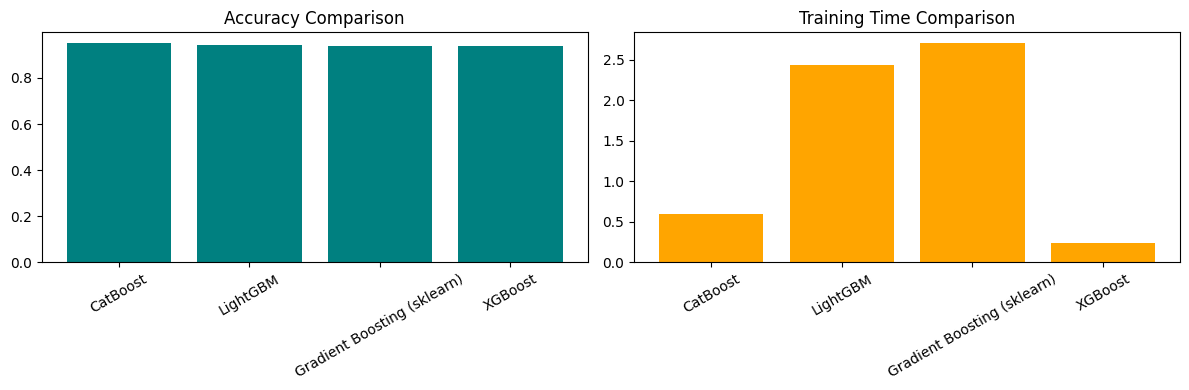

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(df_results["Model"], df_results["Accuracy"], color="teal")
axes[0].set_title("Accuracy Comparison")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(df_results["Model"], df_results["Train Time (s)"], color="orange")
axes[1].set_title("Training Time Comparison")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor

# Same dataset jo hand-calculation me use kiya tha
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 5, 4, 5])

# ---- Step 0: Initial prediction F0 = mean(y) ----
F0 = np.mean(y)
print(f"F0 (initial prediction) = {F0}")

n_estimators = 3
learning_rate = 0.1
F = np.full(y.shape, F0, dtype=float)   # current prediction, same length as y
trees = []

for m in range(n_estimators):
    # ---- residual = negative gradient of squared loss => r_i = y_i - F(x_i) ----
    residual = y - F
    print(f"\nIteration {m+1} residuals: {residual}")

    # ---- fit a small tree (stump) on residuals ----
    tree = DecisionTreeRegressor(max_depth=1)
    tree.fit(X, residual)
    trees.append(tree)

    # ---- update: F_new = F_old + eta * h_m(x) ----
    update = tree.predict(X)
    F = F + learning_rate * update
    print(f"F after iteration {m+1}: {F}")

print(f"\nFinal predictions: {F}")

F0 (initial prediction) = 4.0

Iteration 1 residuals: [-2.  0.  1.  0.  1.]
F after iteration 1: [3.8  4.05 4.05 4.05 4.05]

Iteration 2 residuals: [-1.8  -0.05  0.95 -0.05  0.95]
F after iteration 2: [3.62  4.095 4.095 4.095 4.095]

Iteration 3 residuals: [-1.62  -0.095  0.905 -0.095  0.905]
F after iteration 3: [3.458  4.1355 4.1355 4.1355 4.1355]

Final predictions: [3.458  4.1355 4.1355 4.1355 4.1355]


In [12]:
import xgboost as xgb

# ---- Manually gradient & hessian compute karte hain (squared loss) ----
F0 = np.mean(y)
g = F0 - y          # gradient: dL/dF = F - y
h = np.ones_like(y, dtype=float)   # hessian: d2L/dF2 = 1 (squared loss ke liye constant)

print("Gradients (g):", g)
print("Hessians (h):", h)

lam = 1.0   # L2 regularization
gamma = 0.0 # min split loss

def calc_gain(G_L, H_L, G_R, H_R, lam, gamma):
    """XGBoost split gain formula"""
    term_L = (G_L**2) / (H_L + lam)
    term_R = (G_R**2) / (H_R + lam)
    term_total = ((G_L + G_R)**2) / (H_L + H_R + lam)
    return 0.5 * (term_L + term_R - term_total) - gamma

# ---- Split at x <= 2 (Left: idx 0,1 | Right: idx 2,3,4) ----
G_L, H_L = g[:2].sum(), h[:2].sum()
G_R, H_R = g[2:].sum(), h[2:].sum()

gain = calc_gain(G_L, H_L, G_R, H_R, lam, gamma)
print(f"\nG_L={G_L}, H_L={H_L} | G_R={G_R}, H_R={H_R}")
print(f"Split Gain = {gain:.3f}")

# ---- Optimal leaf weights: w* = -G/(H+lambda) ----
w_L = -G_L / (H_L + lam)
w_R = -G_R / (H_R + lam)
print(f"Leaf weight Left = {w_L:.3f}, Right = {w_R:.3f}")

# ---- Ab actual XGBoost library se compare karte hain ----
X_train = X.reshape(-1, 1)
xgb_model = xgb.XGBRegressor(
    n_estimators=1, max_depth=1, learning_rate=1.0,
    reg_lambda=lam, gamma=gamma, base_score=F0
)
xgb_model.fit(X_train, y)
print("\nXGBoost actual predictions:", xgb_model.predict(X_train))

Gradients (g): [ 2.  0. -1.  0. -1.]
Hessians (h): [1. 1. 1. 1. 1.]

G_L=2.0, H_L=2.0 | G_R=-2.0, H_R=3.0
Split Gain = 1.167
Leaf weight Left = -0.667, Right = 0.500

XGBoost actual predictions: [3.  4.4 4.4 4.4 4.4]


In [13]:
import lightgbm as lgb

# ---- GOSS manual simulation ----
g_abs = np.abs(g)
sorted_idx = np.argsort(-g_abs)   # descending sort by |gradient|
print("Sorted indices by |gradient|:", sorted_idx, "-> values:", g_abs[sorted_idx])

a = 0.2  # top 20% fully kept
b = 0.5  # 50% of remaining sampled

n = len(y)
top_n = max(1, int(a * n))
top_idx = sorted_idx[:top_n]
rest_idx = sorted_idx[top_n:]

rng = np.random.default_rng(42)
sample_n = max(1, int(b * len(rest_idx)))
sampled_rest = rng.choice(rest_idx, size=sample_n, replace=False)

weight_factor = (1 - a) / b
print(f"\nTop kept (full weight=1): {top_idx}")
print(f"Sampled rest (weight={weight_factor:.2f}): {sampled_rest}")

# effective gradient sum estimate (GOSS-style)
goss_gradient_sum = g_abs[top_idx].sum() + weight_factor * g_abs[sampled_rest].sum()
full_gradient_sum = g_abs.sum()
print(f"\nGOSS estimated gradient sum: {goss_gradient_sum:.3f}")
print(f"Full (true) gradient sum: {full_gradient_sum:.3f}")

# ---- Actual LightGBM training ----
X_train = X.reshape(-1, 1).astype(float)
lgb_model = lgb.LGBMRegressor(
    n_estimators=50, learning_rate=0.1,
    num_leaves=4, max_depth=-1,   # leaf-wise growth controlled by num_leaves
    min_child_samples=1, verbosity=-1
)
lgb_model.fit(X_train, y)
print("\nLightGBM predictions:", lgb_model.predict(X_train))

Sorted indices by |gradient|: [0 2 4 1 3] -> values: [2. 1. 1. 0. 0.]

Top kept (full weight=1): [0]
Sampled rest (weight=1.60): [2 3]

GOSS estimated gradient sum: 3.600
Full (true) gradient sum: 4.000

LightGBM predictions: [3.66838458 3.66838458 3.66838458 4.49742311 4.49742311]


In [14]:
from catboost import CatBoostRegressor
import pandas as pd

# ---- Categorical dataset (City feature) jaisa hand-calc example ----
data = pd.DataFrame({
    "city": ["A", "B", "A", "A", "B"],
    "target": [1, 0, 1, 0, 1]
})

a_smooth = 1.0
P_prior = data["target"].mean()   # global prior

# ---- Manual Ordered Target Statistic calculation ----
encoded = []
for k in range(len(data)):
    # sirf pehle wale rows (permutation order = row order yahan)
    prior_rows = data.iloc[:k]
    same_city = prior_rows[prior_rows["city"] == data.iloc[k]["city"]]
    
    sum_y = same_city["target"].sum()
    count = len(same_city)
    
    ts = (sum_y + a_smooth * P_prior) / (count + a_smooth)
    encoded.append(ts)
    print(f"Row {k}: city={data.iloc[k]['city']}, prior_count={count}, "
          f"prior_sum={sum_y}, encoded_value={ts:.3f}")

data["city_encoded"] = encoded
print("\n", data)

# ---- Actual CatBoost - native categorical handling ----
X_cat = data[["city"]]
y_cat = data["target"]

cat_model = CatBoostRegressor(
    iterations=50, learning_rate=0.1, depth=2,
    cat_features=["city"],   # <- CatBoost khud ordered TS + ordered boosting karega
    verbose=0
)
cat_model.fit(X_cat, y_cat)
print("\nCatBoost predictions:", cat_model.predict(X_cat))

Row 0: city=A, prior_count=0, prior_sum=0, encoded_value=0.600
Row 1: city=B, prior_count=0, prior_sum=0, encoded_value=0.600
Row 2: city=A, prior_count=1, prior_sum=1, encoded_value=0.800
Row 3: city=A, prior_count=2, prior_sum=2, encoded_value=0.867
Row 4: city=B, prior_count=1, prior_sum=0, encoded_value=0.300

   city  target  city_encoded
0    A       1      0.600000
1    B       0      0.600000
2    A       1      0.800000
3    A       0      0.866667
4    B       1      0.300000

CatBoost predictions: [0.661537   0.51298858 0.661537   0.661537   0.51298858]


In [15]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time

X_full, y_full = make_classification(n_samples=2000, n_features=10, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

models = {
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, max_depth=3),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, max_depth=3, eval_metric="logloss"),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, max_depth=3, verbosity=-1),
    "CatBoost": CatBoostClassifier(iterations=100, depth=3, verbose=0)
}

for name, model in models.items():
    t0 = time.time()
    model.fit(Xtr, ytr)
    t = time.time() - t0
    acc = accuracy_score(yte, model.predict(Xte))
    print(f"{name:20s} | Accuracy: {acc:.4f} | Time: {t:.3f}s")

GradientBoosting     | Accuracy: 0.9075 | Time: 0.437s
XGBoost              | Accuracy: 0.8800 | Time: 0.035s
LightGBM             | Accuracy: 0.9025 | Time: 0.023s
CatBoost             | Accuracy: 0.9100 | Time: 0.100s
